# ⚖️ Fairness Evaluation for Traffic Signal AI

In this notebook, we assess per-class detection performance on the test set:
- **Precision**, **Recall**, **F1-score** for each vehicle class
- **Detection rate** (TP / GT count) per class  
This uncovers any bias (e.g., bikes vs. trucks).


In [1]:
# Pin numpy to avoid binary‐incompatibility and install YOLOv8 + OpenCV
!pip install --upgrade --force-reinstall \
    numpy==1.23.5 \
    ultralytics==8.2.103 \
    opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.0/763.0 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Copy your backup archive from Drive
!cp /content/drive/MyDrive/backup_yolo_project.zip /content/

# Unzip into a clean working folder
!unzip -q /content/backup_yolo_project.zip -d /content/project/

# Flatten the extra nesting (if your ZIP had a 'content/' prefix)
!mv /content/project/content/datasets     /content/project/datasets
!mv /content/project/content/runs         /content/project/runs
!mv /content/project/content/yolov8s.pt   /content/project/yolov8s.pt


In [3]:
import os, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tqdm import tqdm


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Adjust these if needed
PROJECT = '/content/project'
IMG_DIR  = f'{PROJECT}/datasets/Street-View-1/test/images'
LBL_DIR  = f'{PROJECT}/datasets/Street-View-1/test/labels'
MODEL    = f'{PROJECT}/runs/detect/train/weights/best.pt'

model = YOLO(MODEL)

In [5]:
# from your data.yaml
class_names = ['bicycle','bus','car','motorbike','person','truck']
n_classes   = len(class_names)


In [6]:
def load_gt(label_path, img_path):
    """Return list of (cls, [x1,y1,x2,y2]) in pixels."""
    h,w = cv2.imread(img_path).shape[:2]
    boxes = []
    for line in open(label_path):
        cls, xc,yc,wl,hl = map(float, line.split())
        x1 = (xc - wl/2)*w; y1 = (yc - hl/2)*h
        x2 = (xc + wl/2)*w; y2 = (yc + hl/2)*h
        boxes.append((int(cls), [x1,y1,x2,y2]))
    return boxes

def iou(b1, b2):
    x1,y1,x2,y2 = b1; x3,y3,x4,y4 = b2
    xi1, yi1 = max(x1,x3), max(y1,y3)
    xi2, yi2 = min(x2,x4), min(y2,y4)
    inter = max(0, xi2-xi1)*max(0, yi2-yi1)
    area1 = max(0, x2-x1)*max(0, y2-y1)
    area2 = max(0, x4-x3)*max(0, y4-y3)
    return inter/(area1+area2-inter+1e-6)


In [7]:
# initialize counters
TP = [0]*n_classes
FP = [0]*n_classes
FN = [0]*n_classes

for fname in tqdm(os.listdir(IMG_DIR), desc="Evaluating fairness"):
    if not fname.lower().endswith(('.jpg','.png')): continue
    imgp = os.path.join(IMG_DIR, fname)
    lbp  = os.path.join(LBL_DIR, fname.rsplit('.',1)[0]+'.txt')
    gt   = load_gt(lbp, imgp)
    gt_used = [False]*len(gt)

    # predict
    res = model.predict(imgp, conf=0.25, iou=0.5, device='cpu')[0]
    preds = list(zip(res.boxes.cls.tolist(), res.boxes.xyxy.tolist()))

    # match preds→gt
    for cls_p, box_p in preds:
        best_i, best_iou = -1, 0
        for i, (cls_g, box_g) in enumerate(gt):
            if cls_p==cls_g and not gt_used[i]:
                val = iou(box_p, box_g)
                if val>best_iou:
                    best_iou, best_i = val, i
        if best_iou>=0.5:
            TP[int(cls_p)] += 1
            gt_used[best_i]  = True
        else:
            FP[int(cls_p)] += 1
    # any gt_unmatched → FN
    for i,(cls_g,_) in enumerate(gt):
        if not gt_used[i]:
            FN[cls_g] +=1

# build DataFrame
metrics = []
for i,name in enumerate(class_names):
    p = TP[i]/(TP[i]+FP[i]+1e-6)
    r = TP[i]/(TP[i]+FN[i]+1e-6)
    f = 2*p*r/(p+r+1e-6)
    dr= TP[i]/( (TP[i]+FN[i]) + 1e-6)  # detection rate
    metrics.append({'Class': name,
                    'Precision': p,
                    'Recall': r,
                    'F1-score': f,
                    'Det_Rate': dr})
df = pd.DataFrame(metrics).set_index('Class')
df.style.format("{:.3f}")


Evaluating fairness:   0%|          | 0/322 [00:00<?, ?it/s]


image 1/1 /content/project/datasets/Street-View-1/test/images/screenshot_29364_jpg.rf.8ec663f576d4c27654b30fe42a9ffae2.jpg: 384x640 4 cars, 266.2ms
Speed: 19.1ms preprocess, 266.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


Evaluating fairness:   0%|          | 1/322 [00:04<22:49,  4.27s/it]


image 1/1 /content/project/datasets/Street-View-1/test/images/ant_sales-11185_png_jpg.rf.45a02d562c12c76db2521df8f6c5f581.jpg: 640x640 1 bicycle, 2 cars, 7 motorbikes, 399.5ms
Speed: 2.1ms preprocess, 399.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


Evaluating fairness:   1%|          | 2/322 [00:04<10:40,  2.00s/it]

...


image 1/1 /content/project/datasets/Street-View-1/test/images/image73_png_jpg.rf.8640b0640b6280e2000a3466eda4ba4e.jpg: 640x640 1 bicycle, 3 cars, 1 motorbike, 2 persons, 358.8ms
Speed: 2.1ms preprocess, 358.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


Evaluating fairness: 100%|█████████▉| 321/322 [02:16<00:00,  2.13it/s]


image 1/1 /content/project/datasets/Street-View-1/test/images/image62_png_jpg.rf.b526d4a194328c5fef7129cf8508d49c.jpg: 640x640 1 bicycle, 11 persons, 369.2ms
Speed: 2.3ms preprocess, 369.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


Evaluating fairness: 100%|██████████| 322/322 [02:17<00:00,  2.35it/s]


,Precision,Recall,F1-score,Det_Rate
Class,,,,
bicycle,0.877,0.908,0.892,0.908
bus,0.741,0.952,0.833,0.952
car,0.848,0.941,0.892,0.941
motorbike,0.846,0.866,0.856,0.866
person,0.714,0.871,0.785,0.871
truck,1.000,0.950,0.974,0.950


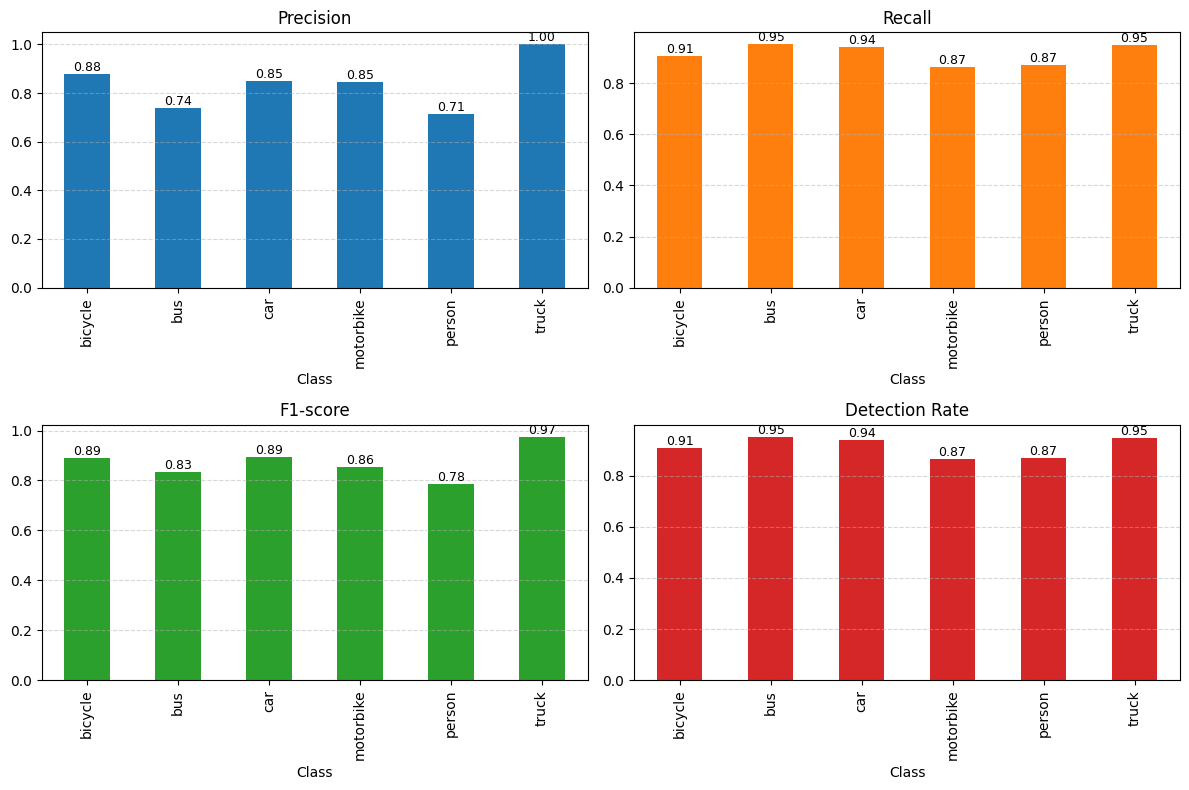

In [8]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
df['Precision'].plot.bar(ax=axes[0,0], color='C0', title='Precision')
df['Recall'].plot.bar(ax=axes[0,1], color='C1', title='Recall')
df['F1-score'].plot.bar(ax=axes[1,0], color='C2', title='F1-score')
df['Det_Rate'].plot.bar(ax=axes[1,1], color='C3', title='Detection Rate')

for ax in axes.flatten():
    ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}", (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


In [9]:
# ── Cell: Avg Confidence & IoU per Class ────────────────────────────────

# Reset counters
TP = [0]*n_classes
FP = [0]*n_classes
FN = [0]*n_classes
sum_conf = [0.0]*n_classes
sum_iou  = [0.0]*n_classes

# Loop over images (same as before)
for fname in tqdm(os.listdir(IMG_DIR), desc="Computing Conf/IoU"):
    if not fname.lower().endswith(('.jpg','png')): continue
    imgp = os.path.join(IMG_DIR, fname)
    lbp  = os.path.join(LBL_DIR, fname.rsplit('.',1)[0]+'.txt')
    gt   = load_gt(lbp, imgp)
    used = [False]*len(gt)

    res = model.predict(imgp, conf=0.25, iou=0.5, device='cpu')[0]
    preds = list(zip(res.boxes.cls.tolist(), res.boxes.xyxy.tolist(), res.boxes.conf.tolist()))

    # match preds→gt
    for cls_p, box_p, c in preds:
        best_i, best_iou = -1, 0
        for i, (cls_g, box_g) in enumerate(gt):
            if cls_p==cls_g and not used[i]:
                val = iou(box_p, box_g)
                if val>best_iou:
                    best_iou, best_i = val, i
        if best_iou>=0.5:
            TP[int(cls_p)] +=1
            used[best_i] = True
            sum_conf[int(cls_p)] += c
            sum_iou[int(cls_p)]  += best_iou
        else:
            FP[int(cls_p)] +=1
    # unmatched GT → FN
    for i,(cls_g,_) in enumerate(gt):
        if not used[i]:
            FN[cls_g]+=1

# Compile into dataframe
adv = []
for i,name in enumerate(class_names):
    tp,fp,fn = TP[i],FP[i],FN[i]
    p = tp/(tp+fp+1e-6)
    r = tp/(tp+fn+1e-6)
    f = 2*p*r/(p+r+1e-6)
    avg_conf = sum_conf[i]/(tp+1e-6)
    avg_i    = sum_iou[i]/(tp+1e-6)
    adv.append({'Class':name,
                'Precision':p,'Recall':r,'F1':f,
                'AvgConf':avg_conf,'AvgIoU':avg_i,
                'FP/Image':fp/len(os.listdir(IMG_DIR)),
                'FN/Image':fn/len(os.listdir(IMG_DIR))})
df_adv2 = pd.DataFrame(adv).set_index('Class').style.format('{:.3f}')
df_adv2


Computing Conf/IoU:   0%|          | 0/322 [00:00<?, ?it/s]


image 1/1 /content/project/datasets/Street-View-1/test/images/screenshot_29364_jpg.rf.8ec663f576d4c27654b30fe42a9ffae2.jpg: 384x640 4 cars, 220.4ms
Speed: 2.9ms preprocess, 220.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)


Computing Conf/IoU:   0%|          | 1/322 [00:00<01:21,  3.94it/s]


image 1/1 /content/project/datasets/Street-View-1/test/images/ant_sales-11185_png_jpg.rf.45a02d562c12c76db2521df8f6c5f581.jpg: 640x640 1 bicycle, 2 cars, 7 motorbikes, 373.7ms
Speed: 2.0ms preprocess, 373.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


Computing Conf/IoU:   1%|          | 2/322 [00:00<01:46,  3.00it/s]

...


image 1/1 /content/project/datasets/Street-View-1/test/images/image73_png_jpg.rf.8640b0640b6280e2000a3466eda4ba4e.jpg: 640x640 1 bicycle, 3 cars, 1 motorbike, 2 persons, 363.0ms
Speed: 2.3ms preprocess, 363.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


Computing Conf/IoU: 100%|█████████▉| 321/322 [02:16<00:00,  2.62it/s]


image 1/1 /content/project/datasets/Street-View-1/test/images/image62_png_jpg.rf.b526d4a194328c5fef7129cf8508d49c.jpg: 640x640 1 bicycle, 11 persons, 350.0ms
Speed: 2.9ms preprocess, 350.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


Computing Conf/IoU: 100%|██████████| 322/322 [02:16<00:00,  2.35it/s]


,Precision,Recall,F1,AvgConf,AvgIoU,FP/Image,FN/Image
Class,,,,,,,
bicycle,0.877,0.908,0.892,0.842,0.869,0.056,0.040
bus,0.741,0.952,0.833,0.886,0.920,0.043,0.006
car,0.848,0.941,0.892,0.791,0.871,1.146,0.404
motorbike,0.846,0.866,0.856,0.731,0.827,0.326,0.276
person,0.714,0.871,0.785,0.642,0.792,0.556,0.205
truck,1.000,0.950,0.974,0.924,0.936,0.000,0.003


Building ConfMat:   0%|          | 0/322 [00:00<?, ?it/s]


image 1/1 /content/project/datasets/Street-View-1/test/images/screenshot_29364_jpg.rf.8ec663f576d4c27654b30fe42a9ffae2.jpg: 384x640 4 cars, 315.9ms
Speed: 3.4ms preprocess, 315.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


Building ConfMat:   0%|          | 1/322 [00:00<01:54,  2.79it/s]


image 1/1 /content/project/datasets/Street-View-1/test/images/ant_sales-11185_png_jpg.rf.45a02d562c12c76db2521df8f6c5f581.jpg: 640x640 1 bicycle, 2 cars, 7 motorbikes, 983.0ms
Speed: 2.3ms preprocess, 983.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


Building ConfMat:   1%|          | 2/322 [00:01<03:56,  1.35it/s]

...

Building ConfMat:  99%|█████████▉| 320/322 [02:20<00:01,  1.95it/s]


image 1/1 /content/project/datasets/Street-View-1/test/images/image73_png_jpg.rf.8640b0640b6280e2000a3466eda4ba4e.jpg: 640x640 1 bicycle, 3 cars, 1 motorbike, 2 persons, 558.6ms
Speed: 6.1ms preprocess, 558.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


Building ConfMat: 100%|█████████▉| 321/322 [02:21<00:00,  1.87it/s]


image 1/1 /content/project/datasets/Street-View-1/test/images/image62_png_jpg.rf.b526d4a194328c5fef7129cf8508d49c.jpg: 640x640 1 bicycle, 11 persons, 558.9ms
Speed: 2.5ms preprocess, 558.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


Building ConfMat: 100%|██████████| 322/322 [02:21<00:00,  2.27it/s]


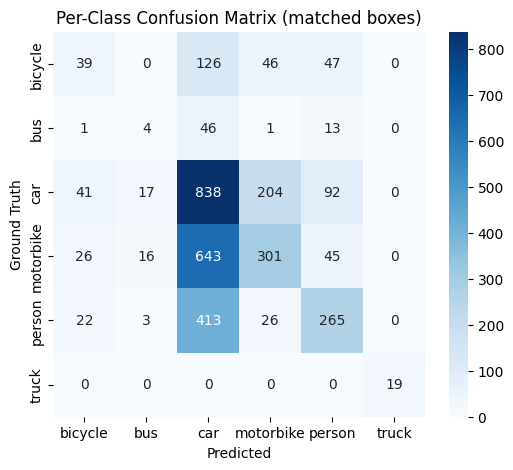

In [10]:
# ── Cell: Class Confusion Matrix ────────────────────────────────────────

import seaborn as sns

# Build confusion counts
conf_mat = np.zeros((n_classes,n_classes), dtype=int)

for fname in tqdm(os.listdir(IMG_DIR), desc="Building ConfMat"):
    if not fname.lower().endswith(('.jpg','png')): continue
    imgp = os.path.join(IMG_DIR, fname)
    lbp  = os.path.join(LBL_DIR, fname.rsplit('.',1)[0]+'.txt')
    gt   = load_gt(lbp, imgp)
    used = [False]*len(gt)

    res = model.predict(imgp, conf=0.25, iou=0.5, device='cpu')[0]
    preds = list(zip(res.boxes.cls.tolist(), res.boxes.xyxy.tolist()))

    for cls_p, box_p in preds:
        best_i,best_iou = -1,0
        for i,(cls_g,box_g) in enumerate(gt):
            if not used[i]:
                val = iou(box_p, box_g)
                if val>best_iou:
                    best_iou, best_i = val,i
        if best_iou>=0.5:
            conf_mat[int(cls_g), int(cls_p)] +=1
            used[best_i]=True

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Ground Truth')
plt.title('Per-Class Confusion Matrix (matched boxes)')
plt.show()


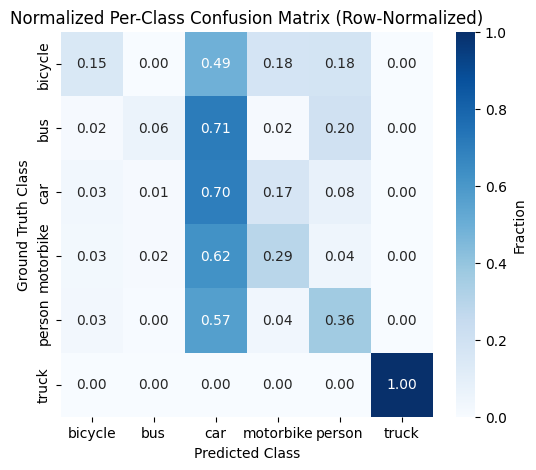

In [12]:
# ── Cell: Normalized Confusion Matrix ──────────────────────────────────

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Assuming conf_mat and class_names already exist

# 1) Compute row sums
row_sums = conf_mat.sum(axis=1, keepdims=True)

# 2) Avoid division by zero
row_sums[row_sums == 0] = 1

# 3) Normalize each row
conf_norm = conf_mat / row_sums

# 4) Plot as heatmap (values 0.00–1.00)
plt.figure(figsize=(6,5))
sns.heatmap(conf_norm, annot=True, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', cbar_kws={'label':'Fraction'})
plt.xlabel('Predicted Class')
plt.ylabel('Ground Truth Class')
plt.title('Normalized Per-Class Confusion Matrix (Row-Normalized)')
plt.show()
